In [1]:
import numpy as np, pandas as pd

In [4]:
df=pd.read_csv('features_insurance.csv')

In [5]:
y=df['charges']

In [6]:
df.columns

Index(['age', 'bmi', 'children', 'charges', 'smoke_enc', 'sex_enc', 'is_obese',
       'smoker_obese', 'northwest', 'southeast', 'southwest', 'bmi_smoker'],
      dtype='object')

In [7]:
x=df[['age', 'bmi', 'children', 'smoke_enc', 'sex_enc', 'is_obese',
       'smoker_obese', 'northwest', 'southeast', 'southwest', 'bmi_smoker']]

## Linear Regression


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [9]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [11]:
lr=LinearRegression()

In [12]:
lr.fit(x_train,y_train)

LinearRegression()

In [13]:
y_pred_lr=lr.predict(x_test)

In [14]:
models = ['Linear Reg', 'Ridge', 'Lasso', 'Decision Tree', 'Random Forest', 'XGBoost']
r2_scores = [0.909, 0.909, 0.909, 0.784, 0.881, 0.846]

(0.7, 1.0)

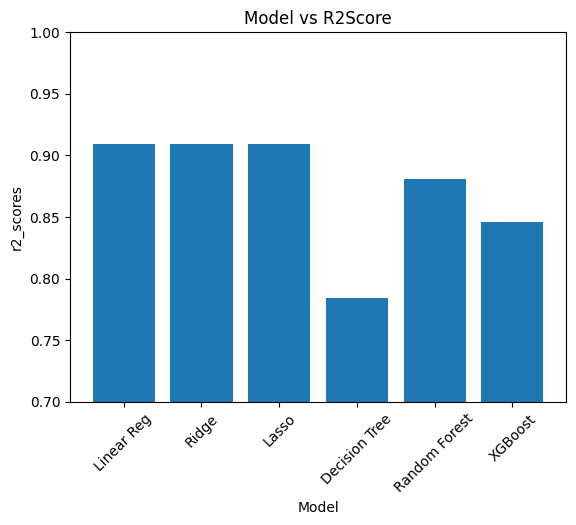

In [16]:
import matplotlib.pyplot as plt

plt.bar(models,r2_scores)
plt.title('Model vs R2Score')
plt.xlabel('Model')
plt.ylabel('r2_scores')
plt.xticks(rotation=45)

plt.ylim(0.7,1.0)

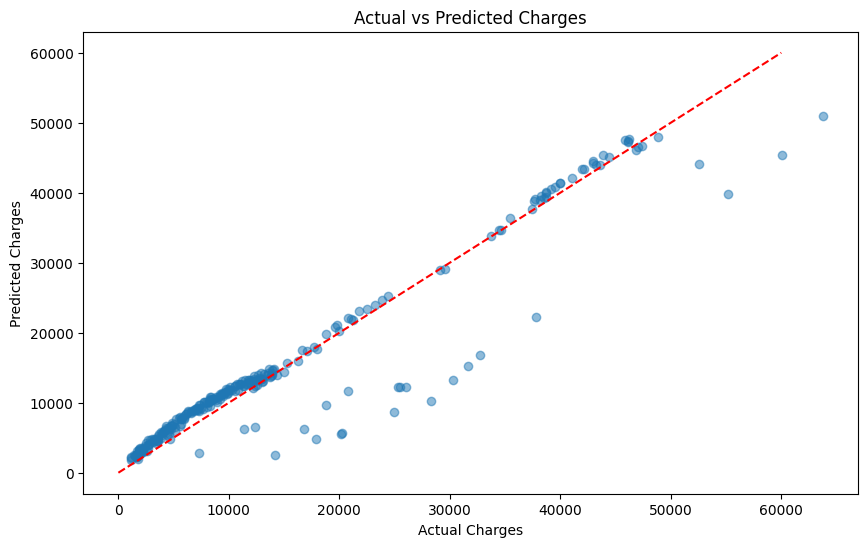

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([0, 60000], [0, 60000], color='red', linestyle='--')
plt.title('Actual vs Predicted Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.show()


Text(0.5, 1.0, 'Residual Plot')

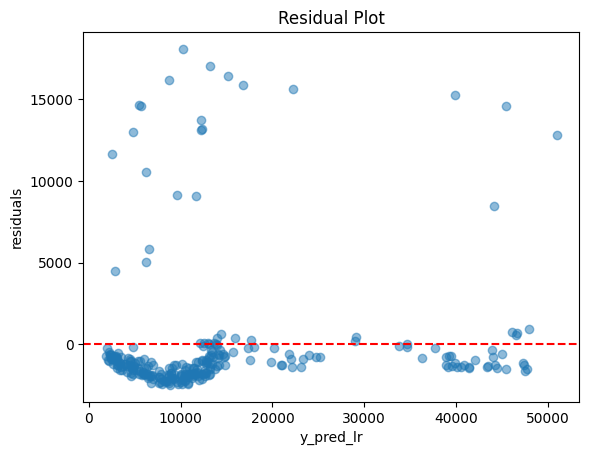

In [21]:
residuals=y_test-y_pred_lr
plt.scatter(y_pred_lr,residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('y_pred_lr')
plt.ylabel('residuals')
plt.title('Residual Plot')

Most residuals cluster near zero, indicating good predictions. Some outliers with residuals up to $18,000 exist — the model under-predicts for certain high-cost individuals.

<BarContainer object of 11 artists>

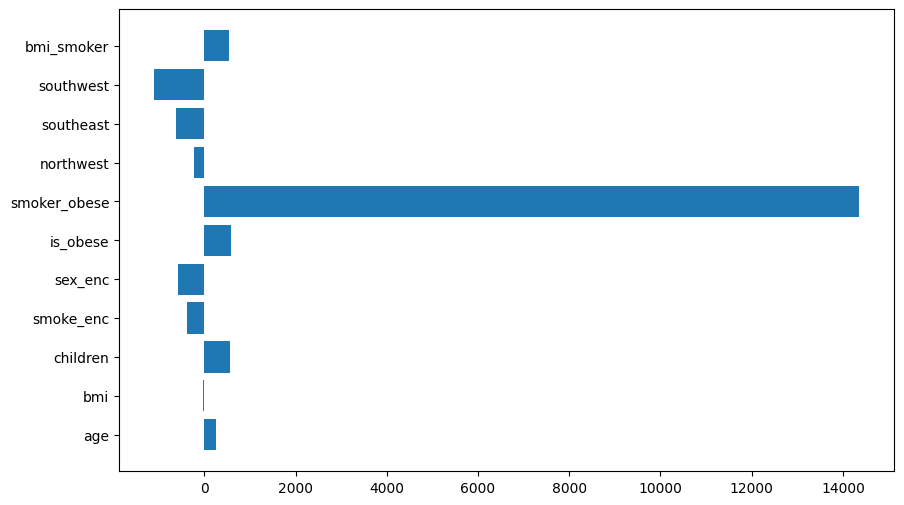

In [22]:
plt.figure(figsize=(10,6))
plt.barh(x.columns, lr.coef_)

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(x_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV R²: {grid.best_score_:.4f}")


Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best CV R²: 0.8343


GridSearchCV tuned Random Forest (R² = 0.834) still underperforms Linear Regression (R² = 0.909). This confirms that our engineered interaction features (smoker_obese, bmi_smoker) linearized the key relationships, making simple linear models the optimal choice for this dataset.